In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d
from scipy.signal import wiener
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 45

8.030570172000001


In [3]:
m, n = 400, 10
w = 30  # width of the bump in # nodes
x = np.linspace(0, 1, m, endpoint=False)
mu = np.linspace(0, 1, n, endpoint=False)
xi = np.array([0.125, 0.35])
sigma = 20
mode = "constant"
rank = 10

In [4]:
print(mu)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


In [5]:
def plot_paramspace(X):
    fig, ax = plt.subplots(figsize=(4.59/2.54, 4.59/2.54))
    plt.imshow(X, interpolation="none", extent=(0, 1, 0, 1), aspect="auto")
    ax.set_xlabel("$\mu$")
    ax.set_ylabel("$x$")
    #ax.set_aspect(1/10)
    plt.show()
    return fig, ax

In [6]:
def bump(x, mu):
    y = np.zeros_like(x)
    i = np.argmin(np.abs(x-mu))
    y[i:(i+w)] = 1.0
    return y

In [7]:
def predict(VT, grid, r, xi):
    method = "linear"
    V_interpolated = np.zeros((r, len(xi)))
    for mode in range(r):
        interpolator = interp1d(grid[0], VT[mode, :], kind=method)
        V_interpolated[mode, :] = interpolator(xi)
    return V_interpolated

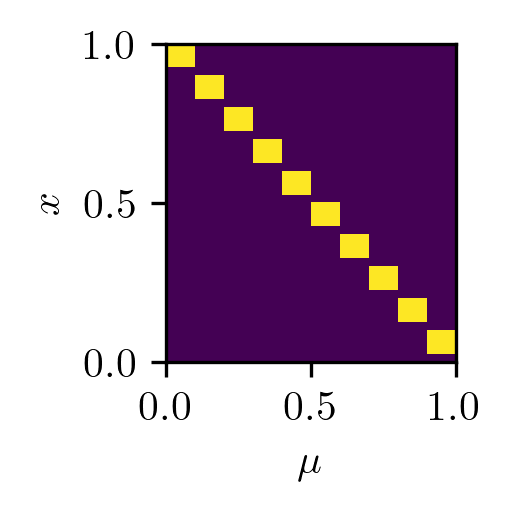

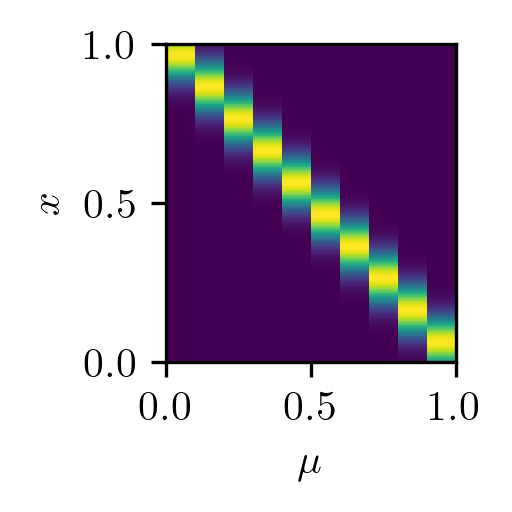

In [8]:
X = np.zeros((m, n))
X_c = np.zeros_like(X)
for j, mu_j in enumerate(mu):
    y = bump(x, mu_j)
    X[:, j] = y
    X_c[:, j] = gaussian_filter1d(y, sigma, mode=mode, cval=0, truncate=20)
plot_paramspace(X)
plt.show()
plot_paramspace(X_c)
plt.show()

In [9]:
U, S, VT = np.linalg.svd(X, False)
U_c, S_c, VT_c = np.linalg.svd(X_c, False)

In [10]:
print(X.T@X)
print(S**2)
print(S_c**2)


[[30.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. 30.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. 30.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. 30.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. 30.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. 30.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. 30.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. 30.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. 30.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0. 30.]]
[30. 30. 30. 30. 30. 30. 30. 30. 30. 30.]
[21.93812686 20.33530621 17.9221156  15.0227978  11.98652922  9.12339382
  6.66171677  4.73358413  3.38510397  2.60246957]


array([1.16939398, 1.21460557, 1.29379655, 1.41314009, 1.58202704,
       1.81335326, 2.12210831, 2.51747738, 2.97697112, 3.39521903])

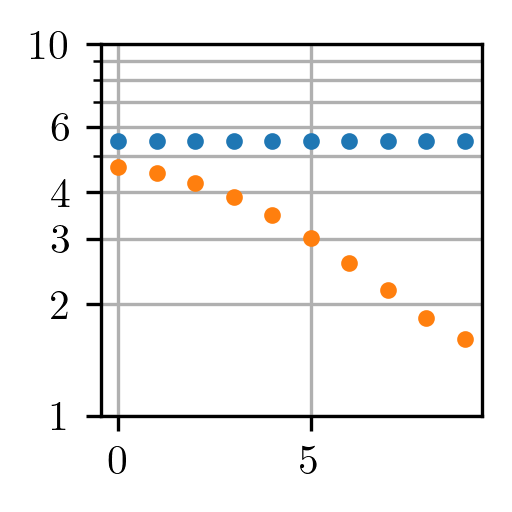

In [11]:
fig, ax = plt.subplots(figsize=(4.59/2.54, 4.59/2.54))
ax.plot(S, ".")
ax.plot(S_c, ".")
ax.set_yscale('log')
ax.set_ylim([1, 10])
#ax.ticklabel_format(useOffset=False, style='plain')
ax.set_yticks([1, 2, 3, 4, 6, 10])
ax.set_yticklabels([1, 2, 3, 4, 6, 10])
#import matplotlib.ticker as mticker
#ax.get_yaxis().set_major_formatter(mticker.ScalarFormatter())
#ax.get_yaxis().set_minor_formatter(mticker.ScalarFormatter())
plt.grid(which="minor")
plt.grid(which="major")
S/S_c

In [12]:
U_c, S_c, VT_c = U_c[:, :rank], S_c[:rank], VT_c[:rank]
U, S, VT = U[:, :rank], S[:rank], VT[:rank]

In [13]:
grid = [mu,]

In [14]:
VT_intp = predict(VT, grid, rank, xi)
X_intp = (U*S) @ VT_intp

VT_intp_c = predict(VT_c, grid, rank, xi)
X_intp_c = (U_c*S_c) @ VT_intp_c

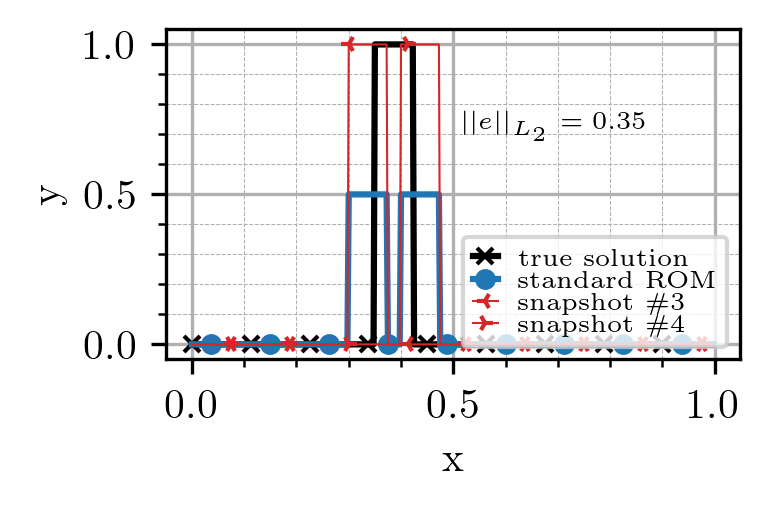

In [15]:
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(x, bump(x, 0.35), "kx-", ms=4, markevery=(0, markevery), label="true solution")
plt.plot(x, X_intp[:, 1], "C0o-", ms=4, markevery=(15, markevery), label="standard ROM")
plt.plot(x, X[:, 3], "C33-", ms=4, lw=.5, markevery=(30, markevery), label="snapshot \#3")
plt.plot(x, X[:, 4], "C34-", ms=4, lw=.5, markevery=(30, markevery), label="snapshot \#4")
#plt.plot(x, X_intp_c[:, 0], "r.-", label="convolution + ROM")


#plt.plot(x, X_c[:, 3], "r--", lw=1, label="closest smoothened snapshot (left)")
#plt.plot(x, X_c[:, 4], "r--", lw=1, label="closest smoothened snapshot (right)")
ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.legend(loc="lower right")
e = np.mean((bump(x, 0.35)-X_intp[:, 0])**2)**.5
ax.text(0.52, 0.72, "$||e||_{L_2}"+"={:.2f}$".format(e), fontsize=6)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [16]:
np.sum((bump(x, 0.35)-X_intp[:, 0])**2)**.5

6.98212002188447

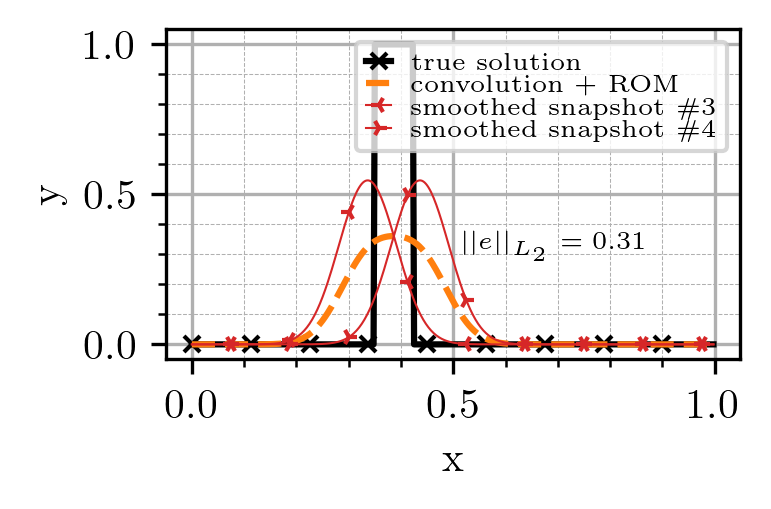

In [17]:
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(x, bump(x, 0.35), "kx-", ms=4, markevery=markevery, label="true solution")
#plt.plot(x, X_intp[:, 0], "b.-", label="ROM")
plt.plot(x, X_intp_c[:, 1], "C1--", ms=4, markevery=markevery, label="convolution + ROM")

#plt.plot(x, X[:, 3], "r--", lw=1, label="closest snapshot (left)")
#plt.plot(x, X[:, 4], "r--", lw=1, label="closest snapshot (right)")

plt.plot(x, X_c[:, 3], "C33-", lw=.5, ms=4, markevery=(30, markevery), label="smoothed snapshot \#3")
plt.plot(x, X_c[:, 4], "C34-", lw=.5, ms=4, markevery=(30, markevery), label="smoothed snapshot \#4")
ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.legend()
e = np.mean((bump(x, 0.35)-X_intp_c[:, 0])**2)**.5
ax.text(0.52, 0.32, "$||e||_{L_2}"+"={:.2f}$".format(e), fontsize=6)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [18]:
np.sum((bump(x, 0.35)-X_intp_c[:, 0])**2)**.5

6.23424868602277

30 30


Text(0, 0.5, 'y')

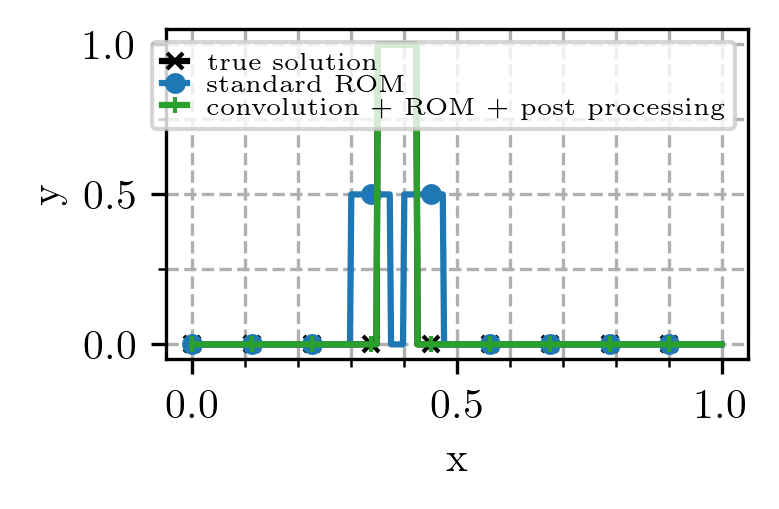

In [19]:
# physics informed post processing. Here: find largest 3 elements.
# other options: wiener deconvolution, threshold methods, ... 
X_intp_c_post = np.zeros_like(X_intp_c)
for j in range(len(xi)):
    ind = np.argpartition(X_intp_c[:, j], -30)[-30:]
    X_intp_c_post[ind, j] = 1
print(np.sum(bump(x, xi[1])>.5), np.sum(X_intp_c_post[:, 1]>.5))
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(x, bump(x, xi[1]), "kx-", ms=4, markevery=markevery, label="true solution")
plt.plot(x, X_intp[:, 1], "C0o-", ms=4, markevery=markevery, label="standard ROM")
plt.plot(x, X_intp_c_post[:, 1], "C2|-", ms=4, markevery=markevery, label="convolution + ROM + post processing")
ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 1, 5, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--')
plt.grid(True, which='major', linestyle='--')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")

30.0


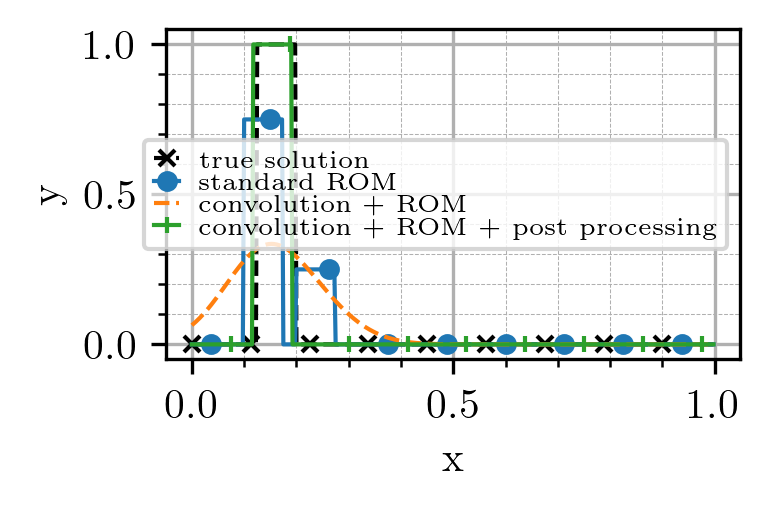

50.0


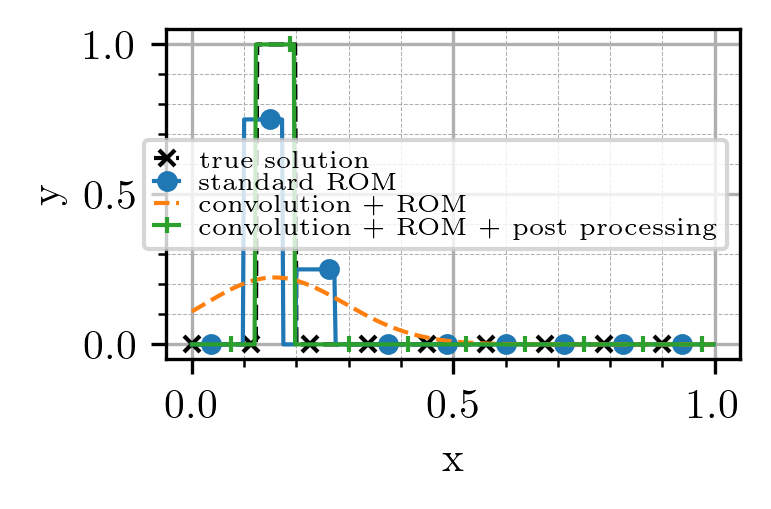

In [21]:
sigmas = np.linspace(0, 100, 1001, endpoint=True)[1:]
#sigmas[-1] = 18.768
e1 = np.zeros_like(sigmas)
e2 = np.zeros_like(sigmas)
e3 = np.zeros_like(sigmas)
e_xi1 = np.zeros_like(sigmas)
e_xi2 = np.zeros_like(sigmas)
ground_truth = np.c_[bump(x, xi[0]), bump(x, xi[1])]
for i, s in enumerate(sigmas):
    for j, mu_j in enumerate(mu):
        X_c[:, j] = gaussian_filter1d(X[:, j], s, mode=mode, cval=0.0)
    U_c, S_c, VT_c = np.linalg.svd(X_c, False)
    U_c, S_c, VT_c = U_c[:, :rank], S_c[:rank], VT_c[:rank]

    VT_intp_c = predict(VT_c, grid, rank, xi)
    X_intp_c = (U_c*S_c) @ VT_intp_c
    X_intp_c_post = np.zeros_like(X_intp_c)
    for j in range(len(xi)):
        ind = np.argpartition(X_intp_c[:, j], -30)[-30:]
        
        X_intp_c_post[ind, j] = 1
    #print(np.sum(bump(x, 0.35) > .5), np.sum(X_intp_c_post[:, 0] > .5))

    e1[i] = np.sum((ground_truth-X_intp)**2)**.5
    e2[i] = np.sum((ground_truth-X_intp_c)**2)**.5
    e3[i] = np.sum((ground_truth-X_intp_c_post)**2)**.5
    e_xi1[i] = np.sum((ground_truth[:, 0]-X_intp_c_post[:, 0])**2)**.5
    e_xi2[i] = np.sum((ground_truth[:, 1]-X_intp_c_post[:, 1])**2)**.5
    if np.round(s, decimals=2) in [0.0, 30., 50]:
        print(s, )
        fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
        #plt.plot(x, X_intp_c_post, "r.")
        #plt.plot(x, X_intp_c_post, "r.")
        plt.plot(x, ground_truth[:, 0], "kx--", ms=4, lw=1, markevery=(0, markevery), label="true solution")
        plt.plot(x, X_intp[:, 0], "C0o-", ms=4, lw=1, markevery=(15, markevery), label="standard ROM")
        plt.plot(x, X_intp_c[:, 0], "C1--", ms=4, lw=1, label="convolution + ROM")
        plt.plot(x, X_intp_c_post[:, 0], "C2|-", ms=4, lw=1, markevery=(30, markevery), label="convolution + ROM + post processing")
        plt.legend()
        plt.xlabel("x")
        plt.ylabel("y")
        #plt.title("{:.3f}, {:.3f}, {:.3f}".format(e1[i], e2[i], e3[i]))
        ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
        ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
        plt.grid(True, which='minor', linestyle='--', lw=.25)
        plt.grid(True, which='major', linestyle='-')
        plt.show()
        

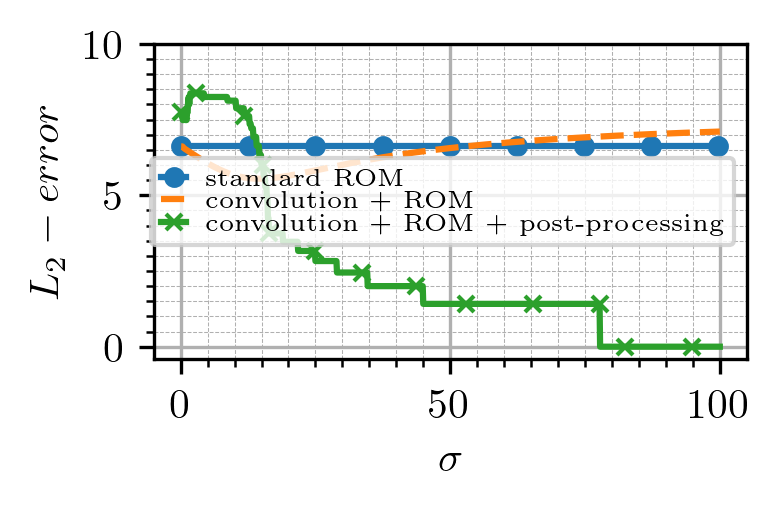

[ 14.6  14.7  14.8  14.9  15.   15.1  15.2  15.3  15.4  15.5  15.6  15.7
  15.8  15.9  16.   16.1  16.2  16.3  16.4  16.5  16.6  16.7  16.8  16.9
  17.   17.1  17.2  17.3  17.4  17.5  17.6  17.7  17.8  17.9  18.   18.1
  18.2  18.3  18.4  18.5  18.6  18.7  18.8  18.9  19.   19.1  19.2  19.3
  19.4  19.5  19.6  19.7  19.8  19.9  20.   20.1  20.2  20.3  20.4  20.5
  20.6  20.7  20.8  20.9  21.   21.1  21.2  21.3  21.4  21.5  21.6  21.7
  21.8  21.9  22.   22.1  22.2  22.3  22.4  22.5  22.6  22.7  22.8  22.9
  23.   23.1  23.2  23.3  23.4  23.5  23.6  23.7  23.8  23.9  24.   24.1
  24.2  24.3  24.4  24.5  24.6  24.7  24.8  24.9  25.   25.1  25.2  25.3
  25.4  25.5  25.6  25.7  25.8  25.9  26.   26.1  26.2  26.3  26.4  26.5
  26.6  26.7  26.8  26.9  27.   27.1  27.2  27.3  27.4  27.5  27.6  27.7
  27.8  27.9  28.   28.1  28.2  28.3  28.4  28.5  28.6  28.7  28.8  28.9
  29.   29.1  29.2  29.3  29.4  29.5  29.6  29.7  29.8  29.9  30.   30.1
  30.2  30.3  30.4  30.5  30.6  30.7  30.8  30.9  3

In [22]:
markevery_sig = 0.1
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
ax.plot(sigmas, e1, "C0o-", markevery=markevery_sig, ms=4, label="standard ROM")
ax.plot(sigmas, e2, "C1--", markevery=markevery_sig, ms=4, label="convolution + ROM")
ax.plot(sigmas, e3, "C2x-", markevery=markevery_sig, ms=4, label="convolution + ROM + post-processing")
#ax.plot(sigmas, e3*e2, "k--", markevery=markevery_sig, ms=4, label="convolution + ROM + post-processing")
plt.xlabel("$\sigma$")
plt.ylabel("$L_2- error$")

plt.legend()
ax.set_xticks(np.linspace(0, 100, 21, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 10, 21, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
#plt.ylim([0, 0.1])
plt.show()
print(sigmas[e1>e3])
print(sigmas[0==e3])

0.125 77.8


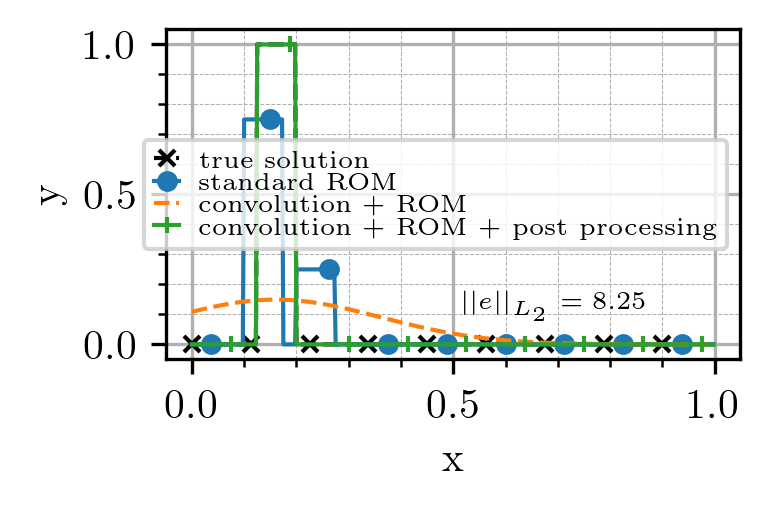

0.35000000000000003 77.8


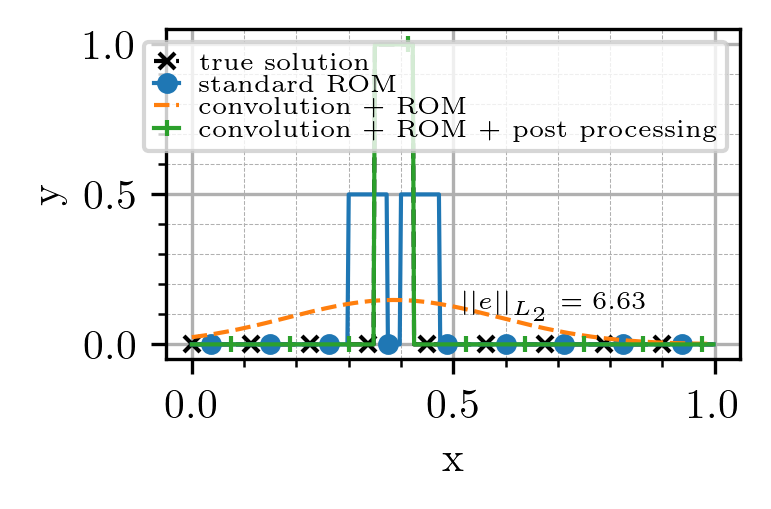

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [23]:
_sigma = 77.8
_X_c = np.zeros_like(X_c)
for j, mu_j in enumerate(mu):
    _X_c[:, j] = gaussian_filter1d(X[:, j], _sigma, mode=mode, cval=0.0)
U_c, S_c, VT_c = np.linalg.svd(_X_c, False)
U_c, S_c, VT_c = U_c[:, :rank], S_c[:rank], VT_c[:rank]
e1_m = np.zeros_like(x)
e2_m = np.zeros_like(x)
e3_m = np.zeros_like(x)

for i, _mu_ in enumerate(x[x<=0.9]):
    
    _ground_truth = bump(x, _mu_)

    _VT_intp = predict(VT, grid, rank, [_mu_])
    _X_intp = (U*S) @ _VT_intp

    _VT_intp_c = predict(VT_c, grid, rank, [_mu_])
    _X_intp_c = (U_c*S_c) @ _VT_intp_c

    _X_intp_c_post = np.zeros_like(_X_intp_c)
    for j in range(len(xi)):
        ind = np.argpartition(_X_intp_c[:, 0], -30)[-30:]
        _X_intp_c_post[ind, 0] = 1
    
    e1_m[i] = np.mean((_ground_truth-_X_intp[:, 0])**2)**.5
    e2_m[i] = np.mean((_ground_truth-_X_intp_c[:, 0])**2)**.5
    e3_m[i] = np.mean((_ground_truth-_X_intp_c_post[:, 0])**2)**.5
    if np.round(_mu_, decimals=4) in [0.125, 0.35]:
        print(_mu_, _sigma)
        fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
        #plt.plot(x, X_intp_c_post, "r.")
        #plt.plot(x, X_intp_c_post, "r.")
        plt.plot(x, _ground_truth, "kx--", ms=4, lw=1, markevery=(0, markevery), label="true solution")
        plt.plot(x, _X_intp[:, 0], "C0o-", ms=4, lw=1, markevery=(15, markevery), label="standard ROM")
        plt.plot(x, _X_intp_c[:, 0], "C1--", ms=4, lw=1, label="convolution + ROM")
        plt.plot(x, _X_intp_c_post[:, 0], "C2|-", ms=4, lw=1, markevery=(30, markevery), label="convolution + ROM + post processing")
        plt.legend()
        plt.xlabel("x")
        plt.ylabel("y")
        #plt.title("{:.3f}, {:.3f}, {:.3f}".format(e1[i], e2[i], e3[i]))
        ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
        ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
        plt.grid(True, which='minor', linestyle='--', lw=.25)
        plt.grid(True, which='major', linestyle='-')
        ax.text(0.52, 0.12, "$||e||_{L_2}"+"={:.2f}$".format(e3[i]), fontsize=6)
        plt.show()
np.linspace(0, 1, 11, endpoint=True)


Text(0, 0.5, 'error')

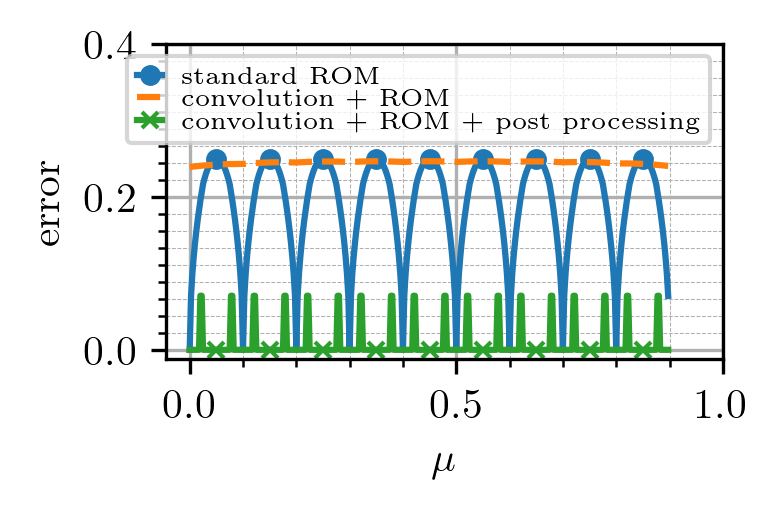

In [24]:
markevery = 40
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
ax.plot(x[:i], e1_m[:i], "C0o-", ms=4, markevery=(20, markevery), label="standard ROM")
ax.plot(x[:i], e2_m[:i], "C1--", ms=4, markevery=markevery, label="convolution + ROM")
ax.plot(x[:i], e3_m[:i], "C2x-", ms=4, markevery=(20, markevery), label="convolution + ROM + post processing")
plt.legend()
ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, .4, 19, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.xlabel("$\mu$")
plt.ylabel("error")

In [25]:
print(np.mean(e1_m[:i]), np.mean(e3_m[:i]), np.mean(e3_m[:i])/np.mean(e1_m[:i]))

0.19197582364019952 0.0070710678118654745 0.036833116159032855
